# FERM 3 — Assignment 2: Value at Risk and Conditional Value at Risk

**Data:** the same 23 stocks and 502 daily returns as the previous quiz
(2016-01-04 → 2017-12-28), in `var_cvar.xlsx`, sheet `Daily_Returns_Raw_Data`.
The file is byte-for-byte the same data as `portfolio_optimization/portfolio.xlsx`
(verified below to 3e-18).

This notebook mirrors the workbook cell-for-cell. Every quantity computed in Python
has a named Excel counterpart on one of the four question sheets, and the two agree
to ~15 significant digits.

| Q | Question | Answer |
|---|---|---|
| 1 | Greatest Variance, $\mathrm{VaR}_{0.9}$, $\mathrm{CVaR}_{0.9}$ | **ACB, ACB, ACB** |
| 2 | $\mathrm{VaR}_{0.9}$ of the evenly weighted portfolio | **0.0089** |
| 3 | $\mathrm{CVaR}_{0.9}$ of the evenly weighted portfolio | **0.0158** |
| 4 | $\mathrm{CVaR}_{0.9}(I_2) - \mathrm{CVaR}_{0.9}(I_1)$ | **0.009** |

| Workbook sheet | Contents |
|---|---|
| `Answers` | the four answers, pulled live from the sheets below |
| `Q1_Risk_by_Stock` | 23 × (variance, VaR, CVaR) plus the three argmaxes |
| `Q2&3_Portfolio` | weight vector, 502 portfolio returns, VaR and CVaR |
| `Q4_VaR_vs_CVaR` | the 10-row P&L table and the CVaR difference |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX = "var_cvar.xlsx"
raw = pd.read_excel(XLSX, sheet_name="Daily_Returns_Raw_Data")

tickers = list(raw.columns[1:])
R = raw[tickers].values            # (T x n) matrix of daily returns
T, n = R.shape
ALPHA = 0.9

print(f"{T} trading days, {n} stocks")
print(f"{raw['date'].min():%Y-%m-%d} -> {raw['date'].max():%Y-%m-%d}")
print(tickers)

# the assignment says "use the data from the previous quiz" - confirm it is the same data
prev = pd.read_excel("../portfolio_optimization/portfolio.xlsx",
                     sheet_name="Daily_Returns_Raw_Data")
print(f"\nmax |difference| vs the previous quiz's file = "
      f"{np.abs(prev[tickers].values - R).max():.3e}   -> same data")

502 trading days, 23 stocks
2016-01-04 -> 2017-12-28
['IBM', 'GE', 'LLY', 'F', 'BAC', 'KR', 'ITUB', 'GG', 'SIRI', 'ACB', 'VALE', 'PFE', 'CTL', 'T', 'ECA', 'ABEV', 'CVS', 'MRVL', 'CSCO', 'MO', 'BMY', 'WFC', 'HBAN']

max |difference| vs the previous quiz's file = 0.000e+00   -> same data


---

# The three risk measures

Let $r$ be the daily return and define the **loss**

$$L = -r = 1 - \frac{P_{t_{i+1}}}{P_{t_i}}$$

so a positive $L$ is money lost. All three measures below are functions of the
distribution of $L$, but they answer different questions.

## Variance

$$\operatorname{Var}(L) = \operatorname{Var}(r) = \frac{1}{T-1}\sum_{t=1}^{T}(r_t - \bar r)^2$$

Note $\operatorname{Var}(-r) = \operatorname{Var}(r)$ — the sign flip is irrelevant, which
is exactly the criticism of variance as a *risk* measure. It is **symmetric**: a
+5% day contributes as much "risk" as a −5% day. Nobody complains about upside.
It is also fully determined by the second moment, so it is blind to how fat the
left tail is.

## Value at Risk

$$\mathrm{VaR}_\alpha(L) = \inf\{\ell : \Pr(L \le \ell) \ge \alpha\} = F_L^{-1}(\alpha)$$

the $\alpha$-quantile of the loss. In words: *on the worst 10% of days, we lose at
least $\mathrm{VaR}_{0.9}$*. Because $L = -r$, this is equivalently the negative of
the $(1-\alpha)$ quantile of returns:

$$\mathrm{VaR}_\alpha(L) = -\,F_r^{-1}(1-\alpha)$$

VaR fixes variance's symmetry problem — it only looks at the left tail of returns.
But it has two flaws of its own. It says **nothing about how bad things get beyond
the threshold**, and it is **not subadditive**: you can construct portfolios where
$\mathrm{VaR}(A + B) > \mathrm{VaR}(A) + \mathrm{VaR}(B)$, so VaR can punish
diversification. It is therefore not a *coherent* risk measure.

## Conditional Value at Risk (Expected Shortfall)

$$\mathrm{CVaR}_\alpha(L) = \mathbb{E}\big[\,L \mid L > \mathrm{VaR}_\alpha(L)\,\big]$$

the average loss *given that* we are in the bad tail. This is the answer to "when
it goes wrong, how wrong does it go?" CVaR is coherent — in particular subadditive,
so it never penalises diversification — and it is the measure Basel III moved to
for market risk capital. By construction $\mathrm{CVaR}_\alpha \ge \mathrm{VaR}_\alpha$
always.

Question 4 is a purpose-built demonstration of the gap between the last two.

---

# Which empirical estimator? (this choice matters)

With a finite sample there is more than one way to turn "the 90th percentile" into
a number, and they do not agree. Two candidates:

**(a) Interpolated quantile** — Excel's `PERCENTILE.INC`, NumPy's default
`np.quantile`. Sort the $T$ losses ascending and read off position $1 + \alpha(T-1)$,
interpolating linearly between the two neighbouring order statistics.

**(b) Order statistic** — take $k = \lceil \alpha T \rceil$ and use the $k$-th
smallest loss $L_{(k)}$, an actual observation. This is the empirical CDF's
generalised inverse, $\hat F^{-1}(\alpha)$, applied literally.

**Question 4 tells us which one the course uses.** It asserts that the two
investments have *the same* $\mathrm{VaR}_{0.9}$. They differ in exactly one
observation: $-0.021$ becomes $-0.030$, i.e. the worst loss gets worse. Under (a)
that shifts the interpolated 90th percentile from 0.01965 to 0.02055 — *different*
VaR, contradicting the question. Under (b) both give $L_{(9)} = 0.0195$ — *same*
VaR, as stated.

Question 4 also pins down the CVaR convention. Under **strict** conditioning
($L > \mathrm{VaR}$) the tail is one observation for each investment, giving
$0.021$ and $0.030$, and a difference of $0.009$ — an available answer. Under
**weak** conditioning ($L \ge \mathrm{VaR}$) the tail is two observations and the
difference is $0.0045$, which is not on the list.

So throughout:

$$\boxed{\;\mathrm{VaR}_\alpha = L_{(k)},\quad k = \lceil \alpha T\rceil
\qquad
\mathrm{CVaR}_\alpha = \frac{1}{\#\{L_t > \mathrm{VaR}_\alpha\}}\sum_{L_t > \mathrm{VaR}_\alpha} L_t \;}$$

For $T = 502$, $k = \lceil 451.8\rceil = 452$ and the tail holds $502 - 452 = 50$
observations — the worst 10% (well, 9.96%) of days. Every result below is reported
alongside the interpolated variant so you can see the discrepancy is confined to
the 4th–5th decimal and changes no ranking.

In [2]:
def var_hist(r, alpha=ALPHA):
    '''Historical VaR of the loss -r: the k-th smallest loss, k = ceil(alpha*T).'''
    r = np.asarray(r)
    k = int(np.ceil(alpha * len(r)))
    # k-th smallest loss == k-th largest return, negated  ->  Excel: -LARGE(range, k)
    return -np.sort(r)[::-1][k - 1]


def cvar_hist(r, alpha=ALPHA):
    '''CVaR = mean of the losses strictly above VaR.  Excel: -AVERAGEIF(rng,"<"&-VaR).'''
    r = np.asarray(r)
    L = -r
    v = var_hist(r, alpha)
    return L[L > v].mean()


def var_interp(r, alpha=ALPHA):
    '''The PERCENTILE.INC alternative, for comparison only.'''
    return -np.quantile(np.asarray(r), 1 - alpha)


k = int(np.ceil(ALPHA * T))
print(f"alpha = {ALPHA},  T = {T},  k = ceil(alpha*T) = {k},  tail size = T - k = {T - k}")

alpha = 0.9,  T = 502,  k = ceil(alpha*T) = 452,  tail size = T - k = 50


### Excel equivalent (the estimator itself)

The whole convention is three formulas. With the 502 returns of one asset in
`Daily_Returns_Raw_Data!B2:B503`:

```excel
B5    =ROUNDUP(0.9*COUNT(Daily_Returns_Raw_Data!B2:B503),0)   ' k = 452
D14   =-LARGE(Daily_Returns_Raw_Data!B$2:B$503,$B$5)          ' VaR
E14   =-AVERAGEIF(Daily_Returns_Raw_Data!B$2:B$503,"<"&-D14)  ' CVaR
```

Two things worth understanding.

`LARGE(range, k)` returns the $k$-th **largest** return. Sorting losses ascending is
the same as sorting returns descending, so the $k$-th smallest loss is the $k$-th
largest return with the sign flipped. That is why `-LARGE(...,452)` and not
`SMALL(...,452)`.

`AVERAGEIF(range,"<"&-D14)` averages the returns strictly below $-\mathrm{VaR}$ —
i.e. the losses strictly above VaR — and negating gives CVaR. The `"<"&` syntax
builds the criterion string by concatenation; `"<"&-D14` with `D14 = 0.008946`
becomes the text `"<-0.008946"`. Writing `"<-D14"` instead would compare against the
literal characters `-D14` and return `#DIV/0!`.

---

# Question 1 — Which stock is riskiest under each measure?

Compute all three measures for all 23 stocks and take the argmax of each.

In [3]:
risk = pd.DataFrame({
    "variance": R.var(axis=0, ddof=1),
    "std_dev":  R.std(axis=0, ddof=1),
    "VaR_0.9":  [var_hist(R[:, j])  for j in range(n)],
    "CVaR_0.9": [cvar_hist(R[:, j]) for j in range(n)],
    "VaR_interp": [var_interp(R[:, j]) for j in range(n)],
}, index=tickers)
risk["tail_obs"] = [int(((-R[:, j]) > var_hist(R[:, j])).sum()) for j in range(n)]

print(risk.sort_values("variance", ascending=False).round(6).to_string())
print("\nargmax of each measure:")
for m in ["variance", "VaR_0.9", "CVaR_0.9"]:
    print(f"  {m:<10s} -> {risk[m].idxmax()}   ({risk[m].max():.6f})")

      variance   std_dev   VaR_0.9  CVaR_0.9  VaR_interp  tail_obs
ACB   0.002376  0.048748  0.048230  0.074245    0.048192        50
ECA   0.001407  0.037516  0.038250  0.065887    0.038212        50
VALE  0.001406  0.037496  0.041745  0.065267    0.041738        50
ITUB  0.000701  0.026473  0.024312  0.044944    0.024309        50
GG    0.000642  0.025332  0.025701  0.048336    0.025700        50
CTL   0.000455  0.021333  0.021630  0.040701    0.021612        50
MRVL  0.000411  0.020276  0.017668  0.031265    0.017644        50
KR    0.000366  0.019133  0.018269  0.035158    0.018131        50
ABEV  0.000313  0.017691  0.018657  0.031468    0.018642        50
BAC   0.000296  0.017192  0.015728  0.030525    0.015722        50
HBAN  0.000295  0.017186  0.016554  0.030673    0.016554        50
BMY   0.000284  0.016862  0.014212  0.030855    0.014211        50
F     0.000204  0.014275  0.014926  0.027782    0.014897        50
CVS   0.000193  0.013910  0.014227  0.027711    0.014212      

In [4]:
# the ranking is not an artefact of the estimator choice
alt = pd.DataFrame({
    "order-stat VaR": risk["VaR_0.9"],
    "interpolated VaR": risk["VaR_interp"],
})
print(f"argmax agrees: {alt['order-stat VaR'].idxmax()} vs {alt['interpolated VaR'].idxmax()}")
print(f"max |difference| between the two VaR estimators = "
      f"{(alt['order-stat VaR'] - alt['interpolated VaR']).abs().max():.6f}")
print(f"\ntail sizes: {sorted(set(risk['tail_obs']))}  "
      f"(PFE has 49 not 50 - its VaR observation is tied with the next one)")

argmax agrees: ACB vs ACB
max |difference| between the two VaR estimators = 0.000139

tail sizes: [49, 50]  (PFE has 49 not 50 - its VaR observation is tied with the next one)


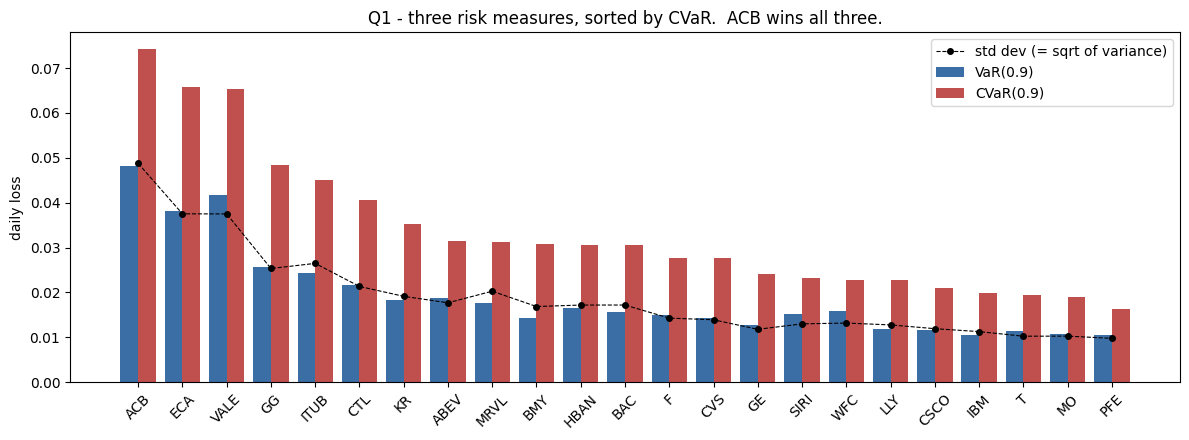

In [5]:
srt = risk.sort_values("CVaR_0.9", ascending=False)
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(srt))
ax.bar(x - 0.2, srt["VaR_0.9"],  0.4, label="VaR(0.9)",  color="#3b6ea5")
ax.bar(x + 0.2, srt["CVaR_0.9"], 0.4, label="CVaR(0.9)", color="#c0504d")
ax.plot(x, srt["std_dev"], "k.--", lw=.8, ms=8, label="std dev (= sqrt of variance)")
ax.set_xticks(x); ax.set_xticklabels(srt.index, rotation=45)
ax.set_ylabel("daily loss"); ax.legend()
ax.set_title("Q1 - three risk measures, sorted by CVaR.  ACB wins all three.")
plt.tight_layout(); plt.show()

### Reading the result

**ACB is the greatest under all three measures**, and not narrowly: its variance is
1.7× the runner-up's and its VaR is 15% above VALE's. ACB is Aurora Cannabis over
2016–17, a period when the stock routinely moved 5–10% in a day on regulatory news.
Its daily volatility is 4.9% against roughly 1.1% for IBM.

The chart shows the more general lesson. The three measures **mostly** agree on the
ordering, because for a single equity the loss distribution is close enough to
symmetric-and-unimodal that all three are driven by the same scale parameter. But
they do not agree exactly — compare ECA and VALE, which swap places between VaR
(VALE higher) and CVaR (ECA higher). ECA's tail beyond its VaR is fatter even though
its VaR threshold is lower. That gap is the entire point of Question 4.

$$\text{Answer: } \textbf{ACB, ACB, ACB}$$

### Excel equivalent (Q1)

Sheet `Q1_Risk_by_Stock`. One row per ticker, rows 14–36, with the raw column letter
tracking the ticker (IBM → `B`, GE → `C`, …, HBAN → `X`):

```excel
B3    0.9                                                      ' alpha (blue = input)
B4    =COUNT(Daily_Returns_Raw_Data!B2:B503)                    ' T   = 502
B5    =ROUNDUP(B3*B4,0)                                         ' k   = 452

B14   =VAR(Daily_Returns_Raw_Data!B$2:B$503)                    ' variance (= VAR.S, /(T-1))
C14   =SQRT(B14)                                                ' std dev
D14   =-LARGE(Daily_Returns_Raw_Data!B$2:B$503,$B$5)            ' VaR(0.9)
E14   =-AVERAGEIF(Daily_Returns_Raw_Data!B$2:B$503,"<"&-D14)    ' CVaR(0.9)
F14   =COUNTIF(Daily_Returns_Raw_Data!B$2:B$503,"<"&-D14)       ' tail size, expect 50
G14   =-PERCENTILE(Daily_Returns_Raw_Data!B$2:B$503,1-$B$3)     ' interpolated alternative
H14   =RANK(B14,$B$14:$B$36)                                    ' rank 1 = riskiest
```

and the three answers, at the top:

```excel
B8    =INDEX($A$14:$A$36,MATCH(MAX($B$14:$B$36),$B$14:$B$36,0))  ' greatest variance
B9    =INDEX($A$14:$A$36,MATCH(MAX($D$14:$D$36),$D$14:$D$36,0))  ' greatest VaR
B10   =INDEX($A$14:$A$36,MATCH(MAX($E$14:$E$36),$E$14:$E$36,0))  ' greatest CVaR
```

`INDEX`/`MATCH` is the argmax idiom: `MATCH` finds the position of the maximum
within the value column, `INDEX` returns the ticker at that position in column A.
The `0` third argument to `MATCH` demands an exact match, which is required for an
unsorted range.

---

# Question 2 — VaR of the evenly weighted portfolio

## Compute the portfolio return series first, not the portfolio VaR from the pieces

The portfolio's daily return is

$$r^p_t = \sum_{i=1}^{23} x_i r_{i,t}, \qquad x_i = \tfrac{1}{23}$$

Apply the weights **day by day** to get one series of 502 portfolio returns, then
take the quantile of *that* series. It is tempting to average the 23 individual
VaRs instead. That is wrong, and wrong in a specific, informative direction:

$$\mathrm{VaR}_\alpha\Big(\sum_i x_i L_i\Big) \;\ne\; \sum_i x_i\,\mathrm{VaR}_\alpha(L_i)$$

because the 23 stocks do not have their bad days simultaneously. Averaging the
individual VaRs gives 0.0191 — 2.1× the correct 0.0089. The
difference is the **diversification benefit**, and it is only visible if you form
the portfolio series before applying the risk measure. Equality would hold only
under perfect correlation.

In [6]:
w = np.full(n, 1 / n)                    # evenly weighted
assert np.isclose(w.sum(), 1.0)

rp = R @ w                               # 502 portfolio daily returns
Lp = -rp                                 # portfolio daily losses

var_p = var_hist(rp)
print(f"portfolio VaR(0.9)        = {var_p:.10f}")
print(f"Q2 ANSWER (4 dp)          = {round(var_p, 4)}")
print()
print(f"interpolated alternative  = {var_interp(rp):.10f}   -> rounds to "
      f"{round(var_interp(rp), 4)} as well")
print(f"naive average of the 23 individual VaRs = {risk['VaR_0.9'].mean():.10f}  <- WRONG, "
      f"{risk['VaR_0.9'].mean() / var_p:.2f}x too big")
print(f"portfolio std dev {rp.std(ddof=1):.6f} vs average stock std dev "
      f"{risk['std_dev'].mean():.6f}")

portfolio VaR(0.9)        = 0.0089464533
Q2 ANSWER (4 dp)          = 0.0089

interpolated alternative  = 0.0089431176   -> rounds to 0.0089 as well
naive average of the 23 individual VaRs = 0.0191407011  <- WRONG, 2.14x too big
portfolio std dev 0.008739 vs average stock std dev 0.019027


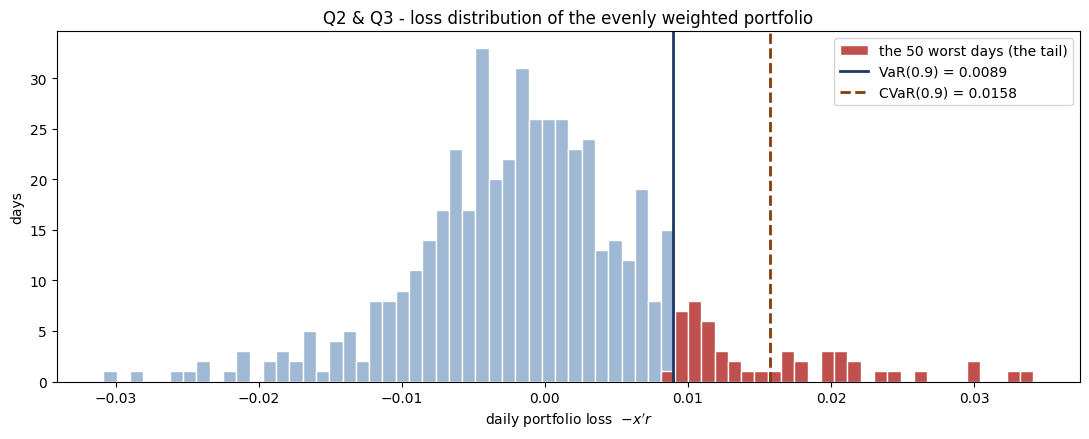

In [7]:
srt = np.sort(Lp)
tail = srt[srt > var_p]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(srt, bins=70, color="#9fb8d4", edgecolor="white")
ax.hist(tail, bins=np.histogram_bin_edges(srt, 70), color="#c0504d", edgecolor="white",
        label=f"the {len(tail)} worst days (the tail)")
ax.axvline(var_p, color="#1f3864", lw=2, label=f"VaR(0.9) = {var_p:.4f}")
ax.axvline(tail.mean(), color="#833c0c", lw=2, ls="--",
           label=f"CVaR(0.9) = {tail.mean():.4f}")
ax.set_xlabel("daily portfolio loss  $-x'r$"); ax.set_ylabel("days")
ax.set_title("Q2 & Q3 - loss distribution of the evenly weighted portfolio")
ax.legend(); plt.tight_layout(); plt.show()

$$\text{Answer: } \mathrm{VaR}_{0.9} = 0.008946 \;\Rightarrow\; \textbf{0.0089}$$

Read it as: on the worst 10% of the 502 days, this portfolio lost at least 0.89% of
its value.

### Excel equivalent (Q2)

Sheet `Q2&3_Portfolio`. The weight vector lives in `AB2:AX2` (editable — set them to
anything summing to 1 and everything downstream updates), and rows 25–526 hold the
502 portfolio returns:

```excel
AB2   =1/$F$4                                                   ' 1/23, copied across to AX2
AZ2   =SUM(AB2:AX2)                                             ' = 1, sanity check

B25   =SUMPRODUCT(Daily_Returns_Raw_Data!B2:X2,$AB$2:$AX$2)     ' x'r for one day
C25   =-B25                                                     ' the loss

F6    =COUNT($B$25:$B$526)                                      ' T = 502
F7    =ROUNDUP(F5*F6,0)                                         ' k = 452
F10   =-LARGE($B$25:$B$526,$F$7)                                ' VaR
F11   =ROUND(F10,4)                                             ' <- Q2 ANSWER
```

`SUMPRODUCT` is the right tool here rather than `MMULT`: we want a single scalar
$x'r_t$ per row, and `SUMPRODUCT` returns a scalar without needing array entry
(Ctrl+Shift+Enter). Since the weights are equal you could write `=AVERAGE(...B2:X2)`
and get the identical number, but the `SUMPRODUCT` form still works when you change
the weights.

---

# Question 3 — CVaR of the same portfolio

Same series, now average the tail beyond the threshold rather than reading the
threshold itself.

In [8]:
cvar_p = cvar_hist(rp)
tail = Lp[Lp > var_p]

print(f"observations strictly above VaR = {len(tail)}  (= T - k = {T - k})")
print(f"portfolio CVaR(0.9)       = {cvar_p:.10f}")
print(f"Q3 ANSWER (4 dp)          = {round(cvar_p, 4)}")
print()
print(f"CVaR / VaR ratio          = {cvar_p / var_p:.4f}")
print(f"worst single day          = {Lp.max():.6f} on {raw['date'][Lp.argmax()]:%Y-%m-%d}")
print()
print("--- sensitivity to the convention (the reason this rounds to 0.0158, not 0.0156) ---")
weak = Lp[Lp >= var_interp(rp)]
print(f"  strict, order-stat VaR  : {len(tail)} obs -> {cvar_p:.6f} -> {round(cvar_p, 4)}")
print(f"  weak,  interpolated VaR : {len(weak)} obs -> {weak.mean():.6f} -> "
      f"{round(weak.mean(), 4)}")

observations strictly above VaR = 50  (= T - k = 50)
portfolio CVaR(0.9)       = 0.0157615975
Q3 ANSWER (4 dp)          = 0.0158

CVaR / VaR ratio          = 1.7618
worst single day          = 0.034161 on 2016-06-23

--- sensitivity to the convention (the reason this rounds to 0.0158, not 0.0156) ---
  strict, order-stat VaR  : 50 obs -> 0.015762 -> 0.0158
  weak,  interpolated VaR : 51 obs -> 0.015628 -> 0.0156


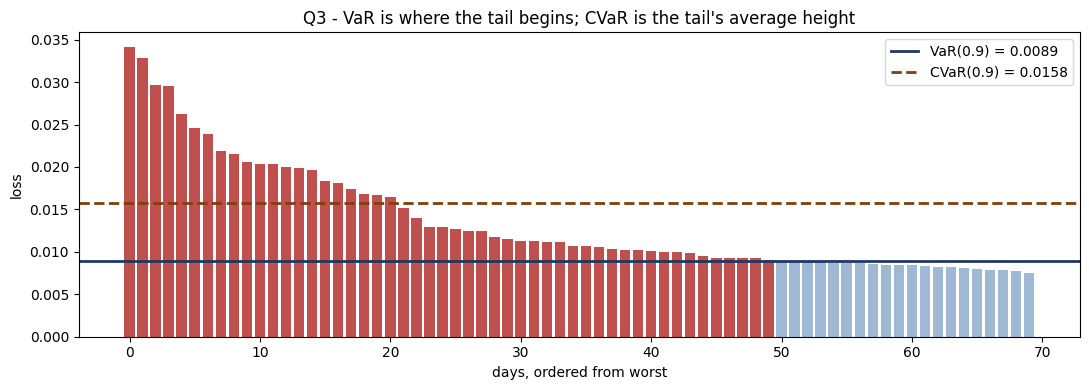

In [9]:
# CVaR is the average height of the red tail; VaR is only where the tail starts
order = np.argsort(Lp)[::-1][:70]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(70), Lp[order], color=["#c0504d"] * len(tail) + ["#9fb8d4"] * (70 - len(tail)))
ax.axhline(var_p, color="#1f3864", lw=2, label=f"VaR(0.9) = {var_p:.4f}")
ax.axhline(cvar_p, color="#833c0c", lw=2, ls="--", label=f"CVaR(0.9) = {cvar_p:.4f}")
ax.set_xlabel("days, ordered from worst"); ax.set_ylabel("loss")
ax.set_title("Q3 - VaR is where the tail begins; CVaR is the tail's average height")
ax.legend(); plt.tight_layout(); plt.show()

$$\text{Answer: } \mathrm{CVaR}_{0.9} = 0.015762 \;\Rightarrow\; \textbf{0.0158}$$

$\mathrm{CVaR}/\mathrm{VaR} = 1.76$. So conditional on having a bad day, the average
bad day is nearly twice as bad as the threshold that defined it — and the worst
single day (2016-06-23, the Brexit referendum) lost 3.4%, 3.8× the VaR. A risk
report quoting only VaR would have hidden all of that.

**A note on the 4th decimal.** This is the one answer sensitive to the convention:
strict conditioning on the order-statistic VaR gives 50 tail observations and
0.015762 → **0.0158**, while weak conditioning on the interpolated VaR gives 51 and
0.015628 → 0.0156. The 51st observation is the least bad one in the tail, so
including it pulls the mean down. Question 4 rules out the weak version (it would
make that question's answer 0.0045, which is not offered), so 0.0158 is the internally
consistent answer. If it is marked wrong, 0.0156 is the alternative — cell `F13` on
the sheet holds the full-precision value either way.

### Excel equivalent (Q3)

```excel
F13   =-AVERAGEIF($B$25:$B$526,"<"&-$F$10)   ' mean of the returns below -VaR, negated
F14   =ROUND(F13,4)                          ' <- Q3 ANSWER
F17   =COUNTIF($B$25:$B$526,"<"&-$F$10)      ' 50, matching T - k
```

`AVERAGEIF` with a `"<"` criterion is the conditional expectation, straight from the
definition $\mathbb{E}[L \mid L > \mathrm{VaR}]$. Cell `F17` is the check that makes
the convention visible: if it read 51 you would be computing the weak-inequality
version instead.

---

# Question 4 — Same VaR, different CVaR

## What the question is engineered to show

Two investments with **identical** P&L except for the single worst observation:
$-0.021$ becomes $-0.030$. Investment 2 is unambiguously worse — it dominates
nothing and is dominated in one state. Any sensible risk measure should say so.

VaR does not. With $n = 10$ and $k = \lceil 9 \rceil = 9$, VaR is the 9th smallest
loss, which is $0.0195$ in **both** columns — the change happened *past* the
threshold, in the region VaR does not look at. You could make that last observation
$-0.99$ and VaR would not move.

CVaR does, because it averages the region beyond the threshold: $0.021$ against
$0.030$.

This is why VaR is not a coherent risk measure and why Basel III replaced it with
Expected Shortfall for trading-book capital. VaR tells you where the cliff edge is;
CVaR tells you how far the drop is.

In [10]:
pnl1 = np.array([-0.012, 0.021, 0.0212, 0.0111, -0.0054, 0.0254, -0.0195, -0.003, 0.008, -0.021])
pnl2 = np.array([-0.012, 0.021, 0.0212, 0.0111, -0.0054, 0.0254, -0.0195, -0.003, 0.008, -0.030])

q4 = pd.DataFrame({"P&L Investment 1": pnl1, "P&L Investment 2": pnl2},
                  index=range(1, 11))
print(q4.to_string())
print(f"\nthey differ only in observation 10:  {pnl1[-1]}  ->  {pnl2[-1]}")

k4 = int(np.ceil(ALPHA * len(pnl1)))
v1, v2 = var_hist(pnl1), var_hist(pnl2)
c1, c2 = cvar_hist(pnl1), cvar_hist(pnl2)

print(f"\nn = {len(pnl1)},  k = ceil(0.9*10) = {k4}  -> VaR is the {k4}th smallest loss")
print(f"  VaR (loss) :  I1 = {v1:.4f}   I2 = {v2:.4f}   identical: {v1 == v2}")
print(f"  CVaR (loss):  I1 = {c1:.4f}   I2 = {c2:.4f}")
print(f"  CVaR (P&L) :  I1 = {-c1:.4f}  I2 = {-c2:.4f}")
print(f"\n  ANSWER   CVaR(I2) - CVaR(I1) = {c2:.4f} - {c1:.4f} = {c2 - c1:+.4f}"
      "   (risk as a positive loss)")
print(f"  same figure carried as a P&L number: {-c2 - (-c1):+.4f}")

    P&L Investment 1  P&L Investment 2
1            -0.0120           -0.0120
2             0.0210            0.0210
3             0.0212            0.0212
4             0.0111            0.0111
5            -0.0054           -0.0054
6             0.0254            0.0254
7            -0.0195           -0.0195
8            -0.0030           -0.0030
9             0.0080            0.0080
10           -0.0210           -0.0300

they differ only in observation 10:  -0.021  ->  -0.03

n = 10,  k = ceil(0.9*10) = 9  -> VaR is the 9th smallest loss
  VaR (loss) :  I1 = 0.0195   I2 = 0.0195   identical: True
  CVaR (loss):  I1 = 0.0210   I2 = 0.0300
  CVaR (P&L) :  I1 = -0.0210  I2 = -0.0300

  ANSWER   CVaR(I2) - CVaR(I1) = 0.0300 - 0.0210 = +0.0090   (risk as a positive loss)
  same figure carried as a P&L number: -0.0090


In [11]:
# why the interpolated estimator cannot be what the question intends
print("order statistic  :  VaR(I1) = %.5f   VaR(I2) = %.5f   -> same, as the question says"
      % (v1, v2))
print("PERCENTILE.INC   :  VaR(I1) = %.5f   VaR(I2) = %.5f   -> different, contradicts it"
      % (var_interp(pnl1), var_interp(pnl2)))
print()
# and why CVaR must use strict inequality
for name, cond in [("strict  L >  VaR", lambda L, v: L > v),
                   ("weak    L >= VaR", lambda L, v: L >= v)]:
    a = (-pnl1)[cond(-pnl1, v1)].mean()
    b = (-pnl2)[cond(-pnl2, v2)].mean()
    print(f"{name}:  tail sizes {cond(-pnl1, v1).sum()}/{cond(-pnl2, v2).sum()},  "
          f"difference = {-b + a:+.4f}   "
          f"{'<- on the answer list' if abs(-b + a) > 0.008 else '<- not on the answer list'}")

order statistic  :  VaR(I1) = 0.01950   VaR(I2) = 0.01950   -> same, as the question says
PERCENTILE.INC   :  VaR(I1) = 0.01965   VaR(I2) = 0.02055   -> different, contradicts it

strict  L >  VaR:  tail sizes 1/1,  difference = -0.0090   <- on the answer list
weak    L >= VaR:  tail sizes 2/2,  difference = -0.0045   <- not on the answer list


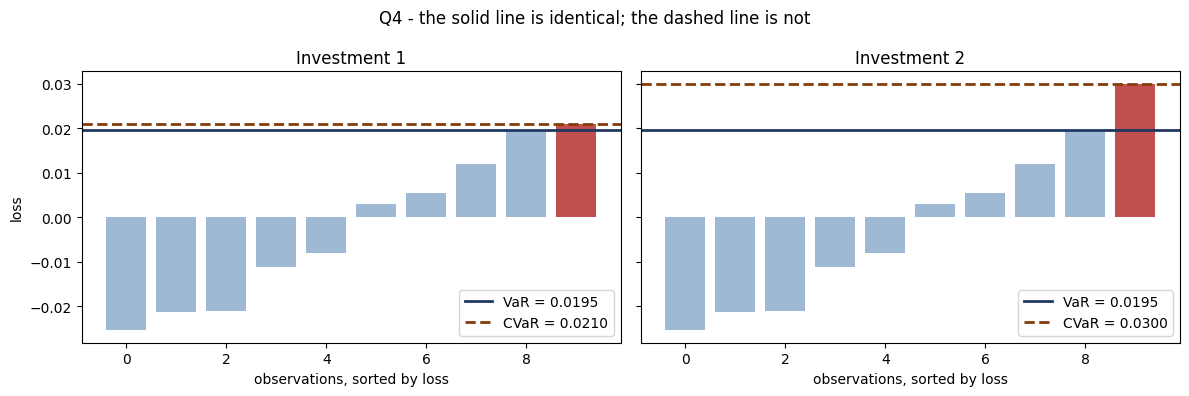

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, p, v, c, name in [(axes[0], pnl1, v1, c1, "Investment 1"),
                          (axes[1], pnl2, v2, c2, "Investment 2")]:
    L = np.sort(-p)
    ax.bar(range(10), L, color=["#c0504d" if x > v else "#9fb8d4" for x in L])
    ax.axhline(v, color="#1f3864", lw=2, label=f"VaR = {v:.4f}")
    ax.axhline(c, color="#833c0c", lw=2, ls="--", label=f"CVaR = {c:.4f}")
    ax.set_title(name); ax.set_xlabel("observations, sorted by loss"); ax.legend()
axes[0].set_ylabel("loss")
plt.suptitle("Q4 - the solid line is identical; the dashed line is not")
plt.tight_layout(); plt.show()

$$\mathrm{CVaR}_{0.9}(I_2) - \mathrm{CVaR}_{0.9}(I_1) = 0.030 - 0.021 = \textbf{0.009}$$

**On the sign.** CVaR is a *risk measure*, and risk measures are reported as positive
losses: $\mathrm{CVaR}(I_1) = 0.021$, $\mathrm{CVaR}(I_2) = 0.030$. Investment 2 is
the riskier one, so the difference is **positive**. Reporting $-0.009$ instead treats
CVaR as a P&L quantity, which is the reporting convention the assignment describes for
Q2 and Q3 ("if you calculated $-0.00835$, submit $0.0084$") — but that guideline is
about how to *submit* a computed number there, not a redefinition of CVaR's sign. Q4
asks for a difference of two risk measures directly, so the risk convention applies.

### Excel equivalent (Q4)

Sheet `Q4_VaR_vs_CVaR`, P&L in `B5:B14` and `C5:C14`:

```excel
F5    =ROUNDUP(F3*F4,0)                         ' k = ceil(0.9*10) = 9
F8    =-LARGE(B5:B14,$F$5)                      ' VaR I1  = 0.0195
G8    =-LARGE(C5:C14,$F$5)                      ' VaR I2  = 0.0195  <- identical
F9    =COUNTIF(B5:B14,"<"&-F8)                  ' 1 observation in the tail
F10   =-AVERAGEIF(B5:B14,"<"&-F8)               ' CVaR I1 = 0.021
G10   =-AVERAGEIF(C5:C14,"<"&-G8)               ' CVaR I2 = 0.030
F16   =G10-F10                                  ' <- Q4 ANSWER = +0.009
F11   =-F10                                     ' the same risk, as a P&L number
F17   =G11-F11                                  ' = -0.009, the sign-flipped version
F13   =-PERCENTILE(B5:B14,1-$F$3)               ' 0.01965 - the estimator that would break
```

Row 13 is worth keeping on the sheet: it shows `PERCENTILE` giving 0.01965 and
0.02055, two *different* VaRs, which is the evidence that the course means the
order statistic in row 8.

---

# Verification

Recalculate the workbook and compare every Excel cell to its Python counterpart.

In [13]:
xl = pd.read_excel(XLSX, sheet_name="Q1_Risk_by_Stock", skiprows=12, nrows=23)
xl = xl.set_index("Ticker")

chk = pd.DataFrame({
    "variance": xl["Variance"] - risk["variance"],
    "VaR":      xl["VaR(0.9)"] - risk["VaR_0.9"],
    "CVaR":     xl["CVaR(0.9)"] - risk["CVaR_0.9"],
})
print(f"Q1  max |Excel - Python| over 23 stocks x 3 measures = {chk.abs().max().max():.2e}")

import openpyxl
vals = openpyxl.load_workbook(XLSX, data_only=True)
p23, p4, ansheet = vals["Q2&3_Portfolio"], vals["Q4_VaR_vs_CVaR"], vals["Answers"]

for label, excel, python in [
    ("Q2 VaR      ", p23["F10"].value, var_p),
    ("Q3 CVaR     ", p23["F13"].value, cvar_p),
    ("Q4 VaR  I1  ", p4["F8"].value,   v1),
    ("Q4 VaR  I2  ", p4["G8"].value,   v2),
    ("Q4 CVaR I1  ", p4["F10"].value,  c1),
    ("Q4 CVaR I2  ", p4["G10"].value,  c2),
    ("Q4 difference", p4["F16"].value, c2 - c1),
]:
    print(f"{label}  Excel {excel!s:<22} Python {python:<22.16f} "
          f"diff {abs(excel - python):.2e}")

print("\nAnswers sheet, read straight out of the workbook:")
for r, q in zip(range(7, 11), ["Q1", "Q2", "Q3", "Q4"]):
    print(f"  {q}: {ansheet[f'C{r}'].value}")

Q1  max |Excel - Python| over 23 stocks x 3 measures = 5.55e-17


Q2 VaR        Excel 0.00894645327668129    Python 0.0089464532766813     diff 3.47e-18
Q3 CVaR       Excel 0.0157615974906995     Python 0.0157615974906995     diff 1.73e-17
Q4 VaR  I1    Excel 0.0195                 Python 0.0195000000000000     diff 0.00e+00
Q4 VaR  I2    Excel 0.0195                 Python 0.0195000000000000     diff 0.00e+00
Q4 CVaR I1    Excel 0.021                  Python 0.0210000000000000     diff 0.00e+00
Q4 CVaR I2    Excel 0.03                   Python 0.0300000000000000     diff 0.00e+00
Q4 difference  Excel 0.009                  Python 0.0090000000000000     diff 1.73e-18

Answers sheet, read straight out of the workbook:
  Q1: ACB, ACB, ACB
  Q2: 0.0089
  Q3: 0.0158
  Q4: 0.009


In [14]:
# independent re-derivation of Q2/Q3 without the helper functions, from first principles
srt = np.sort(-R @ w)                       # losses, ascending
kk = int(np.ceil(0.9 * 502))
v_check = srt[kk - 1]
c_check = srt[kk:].mean()                   # everything strictly beyond, by position
print(f"from-scratch VaR  = {v_check:.16f}  (helper: {var_p:.16f})")
print(f"from-scratch CVaR = {c_check:.16f}  (helper: {cvar_p:.16f})")
assert np.isclose(v_check, var_p, atol=0, rtol=1e-15)
assert np.isclose(c_check, cvar_p, atol=0, rtol=1e-15)

# coherence check: CVaR >= VaR everywhere, and CVaR is subadditive here
assert (risk["CVaR_0.9"] >= risk["VaR_0.9"]).all()
print(f"\nCVaR >= VaR for all 23 stocks: True")
print(f"portfolio CVaR {cvar_p:.6f}  <=  weighted sum of stock CVaRs "
      f"{(w * risk['CVaR_0.9']).sum():.6f}   -> subadditivity holds (diversification pays)")
print("\nALL CHECKS PASSED")

from-scratch VaR  = 0.0089464532766813  (helper: 0.0089464532766813)
from-scratch CVaR = 0.0157615974906995  (helper: 0.0157615974906995)

CVaR >= VaR for all 23 stocks: True
portfolio CVaR 0.015762  <=  weighted sum of stock CVaRs 0.033606   -> subadditivity holds (diversification pays)

ALL CHECKS PASSED


---

# Summary

| Q | Answer | Full precision |
|---|---|---|
| 1 | **ACB, ACB, ACB** | var 0.002376, VaR 0.048230, CVaR 0.074245 |
| 2 | **0.0089** | 0.0089464533 |
| 3 | **0.0158** | 0.0157615975 |
| 4 | **0.009** | 0.0090 exactly |

The through-line: variance treats gains and losses alike, VaR looks only at where
the left tail starts, and CVaR is the only one of the three that sees how deep the
tail goes. Question 1 is the case where they happen to agree; Question 4 is the case
built to make them disagree. Questions 2 and 3 show the third thing the measures
have in common — apply them to the *portfolio's* return series, never to the average
of the individual risks, or you throw away the diversification you paid for.